In [1]:
pip install -U transformers accelerate bitsandbytes peft trl datasets

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 127.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.4/59.4 MB 45.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 465.5/465.5 kB 42.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 511.6/511.6 kB 44.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.7/47.7 MB 54.3 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: transformers
    Found existing installation: transformers 4.57.2
    Uninstalling transformers-4.57.2:
      Successfully uninstalled transformers-4.57.2
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0


In [2]:
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel
import torch

import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, classification_report

import os, json, csv, re
from pathlib import Path

from collections import Counter
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

os.environ["WANDB_DISABLED"] = "true"


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
Model = "mistralai/Mistral-7B-Instruct-v0.3"
BASE_DIR = "/content/drive/MyDrive/Colab Notebooks/DataSci_266_NLP/Final_Project"
OUTPUT_DIR = BASE_DIR + "/Medical_Abstract/mistral_cls_adapter"
os.makedirs(OUTPUT_DIR, exist_ok=True)

Train_path = BASE_DIR + "/Medical_Abstract/train_medical_abstract.csv"
Val_path = BASE_DIR + "/Medical_Abstract/val_medical_abstract.csv"
Test_path = BASE_DIR + "/Medical_Abstract/test_medical_abstract.csv"

Labels = ["Neoplasms", "Digestive system diseases", "Nervous system diseases", "Cardiovascular diseases", "General pathological conditions"]

In [5]:
import json
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline
from tqdm import tqdm
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, classification_report
from datasets import Dataset

In [6]:
OFFLOAD_DIR="./offload"
os.makedirs(OFFLOAD_DIR, exist_ok=True)

In [7]:
# ----------------------------
# CONFIG: Match your training data structure
# ----------------------------
MODEL_CHECKPOINT = OUTPUT_DIR
# ----------------------------
# SETUP
# ----------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
tokenizer = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_CHECKPOINT,
    torch_dtype=torch.float16 if device == "cuda" else torch.float32,
    device_map="auto"
)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

generator = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    pad_token_id=tokenizer.pad_token_id
)



config.json:   0%|          | 0.00/601 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

model-00001-of-00003.safetensors:   0%|          | 0.00/4.95G [00:00<?, ?B/s]

model-00003-of-00003.safetensors:   0%|          | 0.00/4.55G [00:00<?, ?B/s]

model-00002-of-00003.safetensors:   0%|          | 0.00/5.00G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

Device set to use cuda:0


In [8]:
def build_example(text, label=None):
    system = "You are a helpful classifier. Reply with exactly one label from: " + ", ".join(Labels) + "."
    user = f"Text: {text}\nLabel options: " + ", ".join(Labels) + "\nAnswer with one label only."
    return {
        "system": system,
        "user": user,
    }

def df_to_hf(df, is_train=True): # converts df into a Hugging Face dataset
    recs = []
    for _, row in df.iterrows():
        recs.append(build_example(row["text"], Labels[row["label"]] if is_train else None))
    return Dataset.from_list(recs)

In [9]:
# Load validation data
test_df = pd.read_csv(Test_path)
test_ds = df_to_hf(test_df)

In [10]:
test_df.head()

,text,label
0,Health care screening for people with mental h...,4
1,Influence of mental stress on ventricular pump...,3
2,Striatonigral degeneration. A clinicopathologi...,2
3,Multiple myeloma and acute megakaryoblast leuk...,4
4,Large loop excision of the transformation zone...,0


In [11]:
for ex in test_ds.take(5):
  print(ex)

{'system': 'You are a helpful classifier. Reply with exactly one label from: Neoplasms, Digestive system diseases, Nervous system diseases, Cardiovascular diseases, General pathological conditions.', 'user': 'Text: Health care screening for people with mental handicap living in the community OBJECTIVE--To determine what contact people with mental handicap had had with their general practitioner in the previous year; what prescribed drugs they were taking and whether these had been reviewed; when hearing and vision had last been screened; and what medical problems were found on examination. DESIGN--Case series. SETTING-Day centre for adults with mental handicap. SUBJECTS--A balanced sample of 75 of the 150 people attending the day centre. 10 Were excluded because consent was not given. RESULTS--The subjects did not consult their general practitioners more frequently than the general population but were more likely to be taking prescribed drugs, and 57% of these prescriptions had not bee

In [12]:
def formatting_func(example):
    messages = [
        {"role": "system", "content": example["system"]},
        {"role": "user", "content": example["user"]},
    ]
    # Convert chat messages to a single text sequence (no tokenization yet)
    return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

In [13]:
# ----------------------------------
# OUTPUT PATHS
# ----------------------------------
RUN_NAME = "test_preds"                     # change if you like
OUT_DIR = Path (BASE_DIR + "/Medical_Abstract/mistral_cls_adapter")
OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_JSONL = OUT_DIR / f"{RUN_NAME}.jsonl"  # append-safe
OUT_CSV   = OUT_DIR / f"{RUN_NAME}.csv"    # optional rolling CSV
METRICS_JSONL = OUT_DIR / f"{RUN_NAME}.metrics.jsonl"  # per-batch + cumulative
METRICS_CSV   = OUT_DIR / f"{RUN_NAME}.metrics.csv"    # rolling CSV


In [14]:
# ----------------------------------
# LABEL PARSER (simple + robust)
# ----------------------------------
LABELS_SET = {lbl.lower(): lbl for lbl in Labels}  # preserve canonical form

def parse_label(text: str, fallback: str = "Unknown"):
    """
    Extract the first label that appears in the generation.
    Matches whole labels case-insensitively; tolerates extra words/punctuation.
    """
    t = text.strip().lower()
    # Exact match first
    if t in LABELS_SET:
        return LABELS_SET[t]
    # Look for any label as a whole word/phrase
    for lbl in Labels:
        pattern = r"\b" + re.escape(lbl.lower()) + r"\b"
        if re.search(pattern, t):
            return lbl
    # Sometimes models return like: "Label: Anxiety/Stress"
    m = re.search(r"label\s*[:\-]\s*(.+)", t)
    if m:
        cand = m.group(1).strip().lower()
        # try direct
        if cand in LABELS_SET:
            return LABELS_SET[cand]
        # try partial up to punctuation/newline
        cand = re.split(r"[\n\r\.,;!?\-]", cand)[0].strip()
        if cand in LABELS_SET:
            return LABELS_SET[cand]
    return fallback

# ----------------------------------
# INCREMENTAL WRITERS
# ----------------------------------
def append_jsonl(path: Path, records):
    with open(path, "a", encoding="utf-8") as f:
        for r in records:
            f.write(json.dumps(r, ensure_ascii=False) + "\n")

def append_csv(path: Path, records, fieldnames):
    file_exists = path.exists()
    with open(path, "a", encoding="utf-8", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        if not file_exists:
            writer.writeheader()
        writer.writerows(records)

# If labels are stored in val_ds as 'label' or 'status_combined':
def extract_true_label(ex):
    if "label" in ex and ex["label"] is not None:
        return ex["label"]
    if "status_combined" in ex and ex["status_combined"] is not None:
        return ex["status_combined"]
    # If labels are in a separate DataFrame, align by index and return here:
    # return val_df.loc[ex["row_id"], "status_combined"]
    return None

In [15]:
# ----------------------------------
# Build prompts + ground-truth labels (aligned!)
# ----------------------------------

# If test_ds is an HF Dataset of dicts with keys 'system' and 'user'
# build all prompts once (keeps order stable)
prompts = [formatting_func(ex) for ex in test_ds]
true_labels = [Labels[extract_true_label(test_df.iloc[i])] for i in range(len(test_df))]

# Sanity: map any stray labels to canonical spellings
canon = {lbl.lower(): lbl for lbl in Labels}
true_labels = [canon.get((t or "").lower(), t) for t in true_labels]

# ----------------------------------
# Batch inference + incremental example saving + metrics
# ----------------------------------
BATCH_SIZE = 32
example_fieldnames = ["index", "system", "user", "generated_text", "pred_label"]
metric_fieldnames = [
    "batch_start", "batch_end", "batch_size",
    "batch_acc", "batch_f1_macro", "batch_f1_weighted",
    "cum_seen", "cum_acc", "cum_f1_macro", "cum_f1_weighted",
    "unknown_preds_in_batch"
]

all_preds = []
all_trues = []

model.eval()
with torch.no_grad():
    for i in range(0, len(prompts), BATCH_SIZE):
        batch_prompts = prompts[i:i+BATCH_SIZE]
        batch_trues = true_labels[i:i+BATCH_SIZE]

        outputs = generator(
            batch_prompts,
            max_new_tokens=50,
            do_sample=False,
            return_full_text=False,
            batch_size=BATCH_SIZE,
            truncation=True
        )

        # Parse predictions
        batch_preds = []
        example_records = []
        unknown_count = 0

        for j, out in enumerate(outputs):
            idx = i + j
            gen_text = out[0]["generated_text"]
            pred = parse_label(gen_text)
            if pred not in Labels:
                unknown_count += 1
            ex = test_ds[idx]  # contains system/user used to build the prompt

            example_records.append({
                "index": idx,
                "system": ex["system"],
                "user": ex["user"],
                "generated_text": gen_text,
                "pred_label": pred
            })
            batch_preds.append(pred)

        # Save examples incrementally
        append_jsonl(OUT_JSONL, example_records)
        append_csv(OUT_CSV, example_records, example_fieldnames)

        # -------------------------
        # Compute per-batch metrics
        # -------------------------
        # Filter out None ground-truths if present
        mask = [t is not None for t in batch_trues]
        bt_trues = [t for t, m in zip(batch_trues, mask) if m]
        bt_preds = [p for p, m in zip(batch_preds, mask) if m]

        if len(bt_trues) > 0:
            # Any 'Unknown' predictions are treated as-is (will count as wrong)
            batch_acc = accuracy_score(bt_trues, bt_preds)
            batch_f1_macro = f1_score(bt_trues, bt_preds, labels=Labels, average="macro", zero_division=0)
            batch_f1_weighted = f1_score(bt_trues, bt_preds, labels=Labels, average="weighted", zero_division=0)
        else:
            batch_acc = batch_f1_macro = batch_f1_weighted = float("nan")

        # Update cumulative
        all_trues.extend(bt_trues)
        all_preds.extend(bt_preds)

        if len(all_trues) > 0:
            cum_acc = accuracy_score(all_trues, all_preds)
            cum_f1_macro = f1_score(all_trues, all_preds, labels=Labels, average="macro", zero_division=0)
            cum_f1_weighted = f1_score(all_trues, all_preds, labels=Labels, average="weighted", zero_division=0)
        else:
            cum_acc = cum_f1_macro = cum_f1_weighted = float("nan")

        # Save metrics incrementally
        metric_row = {
            "batch_start": i,
            "batch_end": i + len(batch_prompts) - 1,
            "batch_size": len(bt_trues),
            "batch_acc": round(batch_acc, 4) if batch_acc == batch_acc else None,
            "batch_f1_macro": round(batch_f1_macro, 4) if batch_f1_macro == batch_f1_macro else None,
            "batch_f1_weighted": round(batch_f1_weighted, 4) if batch_f1_weighted == batch_f1_weighted else None,
            "cum_seen": len(all_trues),
            "cum_acc": round(cum_acc, 4) if cum_acc == cum_acc else None,
            "cum_f1_macro": round(cum_f1_macro, 4) if cum_f1_macro == cum_f1_macro else None,
            "cum_f1_weighted": round(cum_f1_weighted, 4) if cum_f1_weighted == cum_f1_weighted else None,
            "unknown_preds_in_batch": unknown_count,
        }
        append_jsonl(METRICS_JSONL, [metric_row])
        append_csv(METRICS_CSV, [metric_row], metric_fieldnames)

        # Console display (compact)
        print(
            f"[{i:>5d}-{i+len(batch_prompts)-1:<5d}] "
            f"batch_acc={metric_row['batch_acc']} | "
            f"batch_f1(macro)={metric_row['batch_f1_macro']} | "
            f"cum_acc={metric_row['cum_acc']} | "
            f"cum_f1(macro)={metric_row['cum_f1_macro']} | "
            f"unknown={unknown_count}"
        )

# Optional: final detailed report + confusion matrix
if len(all_trues) > 0:
    print("\nFinal classification report (cumulative):")
    print(classification_report(all_trues, all_preds, labels=Labels, digits=4, zero_division=0))
    print("Confusion matrix (rows=true, cols=pred):")
    print(confusion_matrix(all_trues, all_preds, labels=Labels))

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.
The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


[    0-31   ] batch_acc=0.6562 | batch_f1(macro)=0.6297 | cum_acc=0.6562 | cum_f1(macro)=0.6297 | unknown=0
[   32-63   ] batch_acc=0.5625 | batch_f1(macro)=0.5876 | cum_acc=0.6094 | cum_f1(macro)=0.6075 | unknown=0
[   64-95   ] batch_acc=0.5312 | batch_f1(macro)=0.4534 | cum_acc=0.5833 | cum_f1(macro)=0.559 | unknown=0
[   96-127  ] batch_acc=0.7188 | batch_f1(macro)=0.6869 | cum_acc=0.6172 | cum_f1(macro)=0.604 | unknown=0
[  128-159  ] batch_acc=0.5312 | batch_f1(macro)=0.4683 | cum_acc=0.6 | cum_f1(macro)=0.5883 | unknown=0
[  160-191  ] batch_acc=0.5625 | batch_f1(macro)=0.5503 | cum_acc=0.5938 | cum_f1(macro)=0.5844 | unknown=0
[  192-223  ] batch_acc=0.6562 | batch_f1(macro)=0.6506 | cum_acc=0.6027 | cum_f1(macro)=0.6003 | unknown=0
[  224-255  ] batch_acc=0.5625 | batch_f1(macro)=0.51 | cum_acc=0.5977 | cum_f1(macro)=0.5919 | unknown=0
[  256-287  ] batch_acc=0.5938 | batch_f1(macro)=0.5407 | cum_acc=0.5972 | cum_f1(macro)=0.5865 | unknown=0


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


[  288-319  ] batch_acc=0.5625 | batch_f1(macro)=0.536 | cum_acc=0.5938 | cum_f1(macro)=0.5817 | unknown=0
[  320-351  ] batch_acc=0.4688 | batch_f1(macro)=0.4675 | cum_acc=0.5824 | cum_f1(macro)=0.5749 | unknown=0
[  352-383  ] batch_acc=0.5625 | batch_f1(macro)=0.4895 | cum_acc=0.5807 | cum_f1(macro)=0.5681 | unknown=0
[  384-415  ] batch_acc=0.5312 | batch_f1(macro)=0.4974 | cum_acc=0.5769 | cum_f1(macro)=0.5644 | unknown=0
[  416-447  ] batch_acc=0.5938 | batch_f1(macro)=0.5528 | cum_acc=0.5781 | cum_f1(macro)=0.5647 | unknown=0
[  448-479  ] batch_acc=0.4688 | batch_f1(macro)=0.4331 | cum_acc=0.5708 | cum_f1(macro)=0.5572 | unknown=0
[  480-511  ] batch_acc=0.6562 | batch_f1(macro)=0.5875 | cum_acc=0.5762 | cum_f1(macro)=0.56 | unknown=0
[  512-543  ] batch_acc=0.6562 | batch_f1(macro)=0.5764 | cum_acc=0.5809 | cum_f1(macro)=0.5629 | unknown=0
[  544-575  ] batch_acc=0.5625 | batch_f1(macro)=0.5454 | cum_acc=0.5799 | cum_f1(macro)=0.5626 | unknown=0
[  576-607  ] batch_acc=0.8125 

In [16]:
pred_df = pd.read_csv(OUT_CSV)

In [17]:
pred_df

,index,system,user,generated_text,pred_label
0,0,You are a helpful classifier. Reply with exact...,Text: Health care screening for people with me...,General pathological conditions,General pathological conditions
1,1,You are a helpful classifier. Reply with exact...,Text: Influence of mental stress on ventricula...,Cardiovascular diseases,Cardiovascular diseases
2,2,You are a helpful classifier. Reply with exact...,Text: Striatonigral degeneration. A clinicopat...,Nervous system diseases,Nervous system diseases
3,3,You are a helpful classifier. Reply with exact...,Text: Multiple myeloma and acute megakaryoblas...,Neoplasms,Neoplasms
4,4,You are a helpful classifier. Reply with exact...,Text: Large loop excision of the transformatio...,Neoplasms,Neoplasms
...,...,...,...,...,...
5855,2765,You are a helpful classifier. Reply with exact...,Text: Murine monoclonal anti-idiotype antibody...,Neoplasms,Neoplasms
5856,2766,You are a helpful classifier. Reply with exact...,Text: Gross motor patterns in children with ce...,Nervous system diseases,Nervous system diseases
5857,2767,You are a helpful classifier. Reply with exact...,Text: Hepatic dynamic sequential CT: section e...,Neoplasms,Neoplasms
5858,2768,You are a helpful classifier. Reply with exact...,Text: Indications for distal arterial reconstr...,Cardiovascular diseases,Cardiovascular diseases


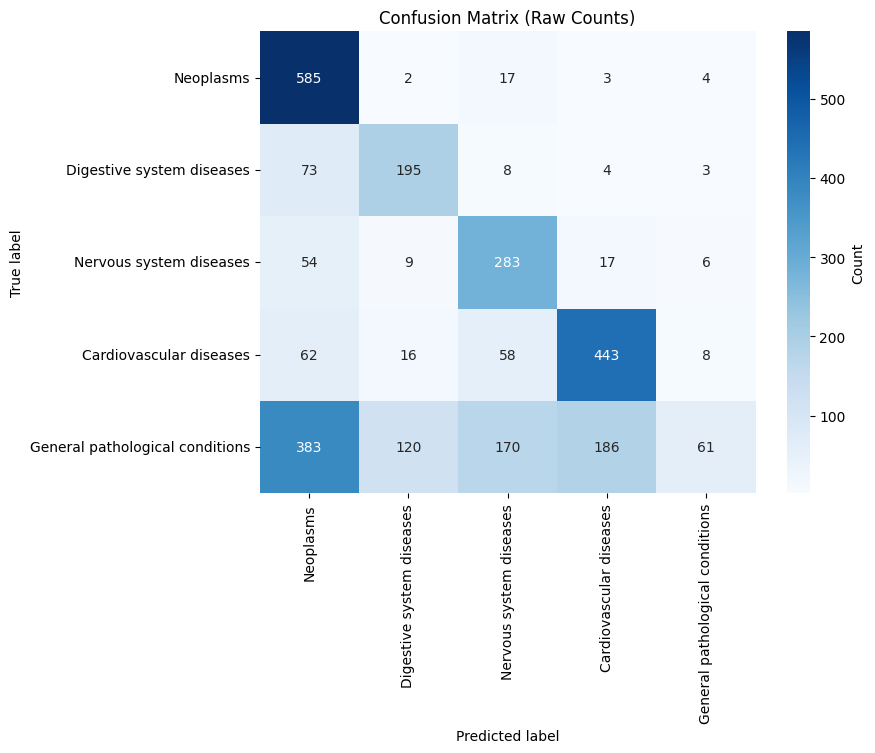

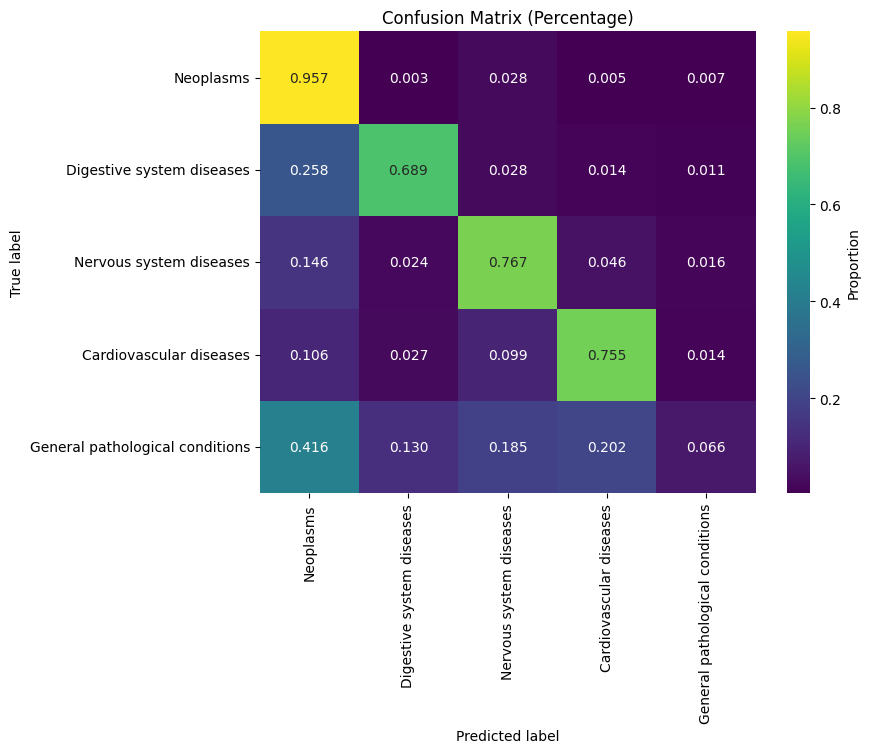

In [18]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Example data
# all_trues = [...]
# all_preds = [...]
# Labels = [...]

# Compute confusion matrix
conf_matrix = confusion_matrix(all_trues, all_preds, labels=Labels)

# Normalize to percentage (row-wise)
conf_matrix_percent = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis]

# Plot 1 — raw counts
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=Labels, yticklabels=Labels, cbar_kws={'label': 'Count'})
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix (Raw Counts)')
plt.show()

# Plot 2 — normalized percentages
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_percent, annot=True, fmt='.3f', cmap='viridis',
            xticklabels=Labels, yticklabels=Labels, cbar_kws={'label': 'Proportion'})
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix (Percentage)')
plt.show()